In [1]:
from sklearn.linear_model import LogisticRegression

from FeDa4Fair.dataset import FairFederatedDataset
from FeDa4Fair.utils.data_utils import generate_multiobjective_bias
from FeDa4Fair.visualization import plot_multi_attribute_fairness

In [2]:
num_clients = 100
group_split_idx = 50
client_names = [str(i) for i in range(num_clients)]

# We use the new generate_multiobjective_bias function which allows
# defining multiple attribute modifications per group in a single structure.

group_configs = [
    {
        "group_id": "Group A",
        "num_clients": group_split_idx,
        "configs": [
            # Mitigate sex_binary
            {"attribute": "sex_binary", "mitigate": True},
            # Bias Marital_status (Drop value 0)
            {
                "attribute": "Marital_status",
                "value": 0,
                "drop_mean": 0.3,
                "drop_std": 0.1,
                "flip_mean": 0.2,
                "flip_std": 0.05,
            },
        ],
    },
    {
        "group_id": "Group B",
        "num_clients": num_clients - group_split_idx,
        "configs": [
            # Bias sex_binary (Drop value 1)
            {
                "attribute": "sex_binary",
                "value": 1,
                "drop_mean": 0.4,
                "drop_std": 0.1,
                "flip_mean": 0.3,
                "flip_std": 0.05,
            },
            # Mitigate Marital_status
            {"attribute": "Marital_status", "mitigate": True},
        ],
    },
]

modifications = generate_multiobjective_bias(num_clients, group_configs, client_names)

/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/utils.py:109: UserWarning: The currently tested dataset are ['mnist', 'ylecun/mnist', 'cifar10', 'uoft-cs/cifar10', 'fashion_mnist', 'zalando-datasets/fashion_mnist', 'sasha/dog-food', 'zh-plus/tiny-imagenet', 'scikit-learn/adult-census-income', 'cifar100', 'uoft-cs/cifar100', 'svhn', 'ufldl-stanford/svhn', 'sentiment140', 'stanfordnlp/sentiment140', 'speech_commands', 'LIUM/tedlium', 'flwrlabs/femnist', 'flwrlabs/ucf101', 'flwrlabs/ambient-acoustic-context', 'jlh/uci-mushrooms', 'Mike0307/MNIST-M', 'flwrlabs/usps', 'scikit-learn/iris', 'flwrlabs/pacs', 'flwrlabs/cinic10', 'flwrlabs/caltech101', 'flwrlabs/office-home', 'flwrlabs/fed-isic2019']. Given: lucacorbucci/Dutch_census_binary_marital_status.
  warnings.warn(


Preparing dataset...


/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(
/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/.venv/lib/python3.12/site-packages/flwr_datasets/metrics/utils.py:130: UserWarning: The verbose names can not be established. The column specified by 'column_name' needs to be of type 'ClassLabel' to create a verbose names. The available names will used.
  warnings.warn(
/Users/lucacorbucci/Documents/GitHub/FeDa4Fair/src/FeDa4Fair/dataset/fair_dataset.py:215: UserWarning: Your current data contains columns with sensitive attributes. If these should not be in the training data later, please remove them before training.
  self._prepare_dataset()


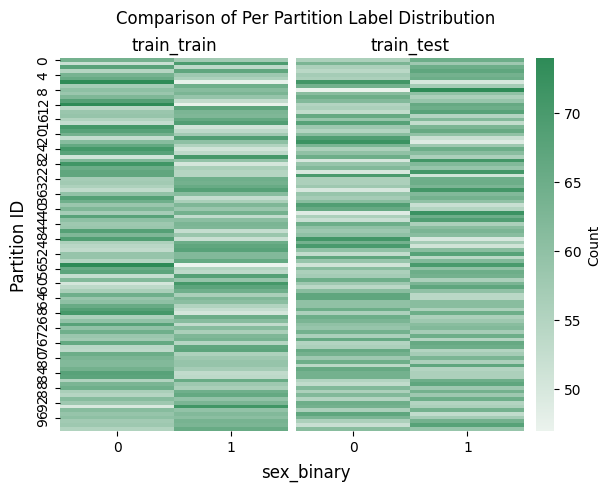

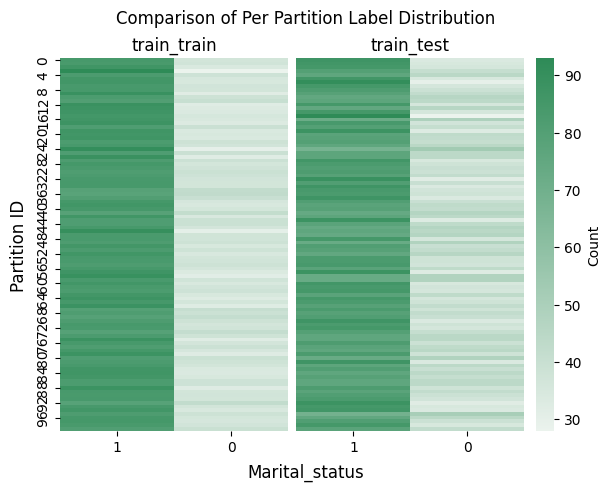

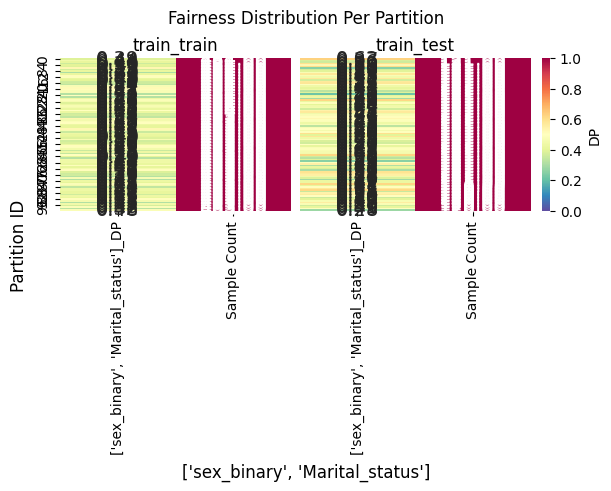

In [3]:
fds = FairFederatedDataset(
    dataset="lucacorbucci/Dutch_census_binary_marital_status",
    split="all",
    partitioners={"train": num_clients},
    label_name="occupation_binary",
    sensitive_attributes=["sex_binary", "Marital_status"],
    modification_dict=modifications,
    fl_setting="cross-silo",
    perc_train_val_test=[0.8, 0.2],
    client_names=client_names,
)

print("Preparing dataset...")
fds.prepare()


Generating fairness plots (Model Fairness)...


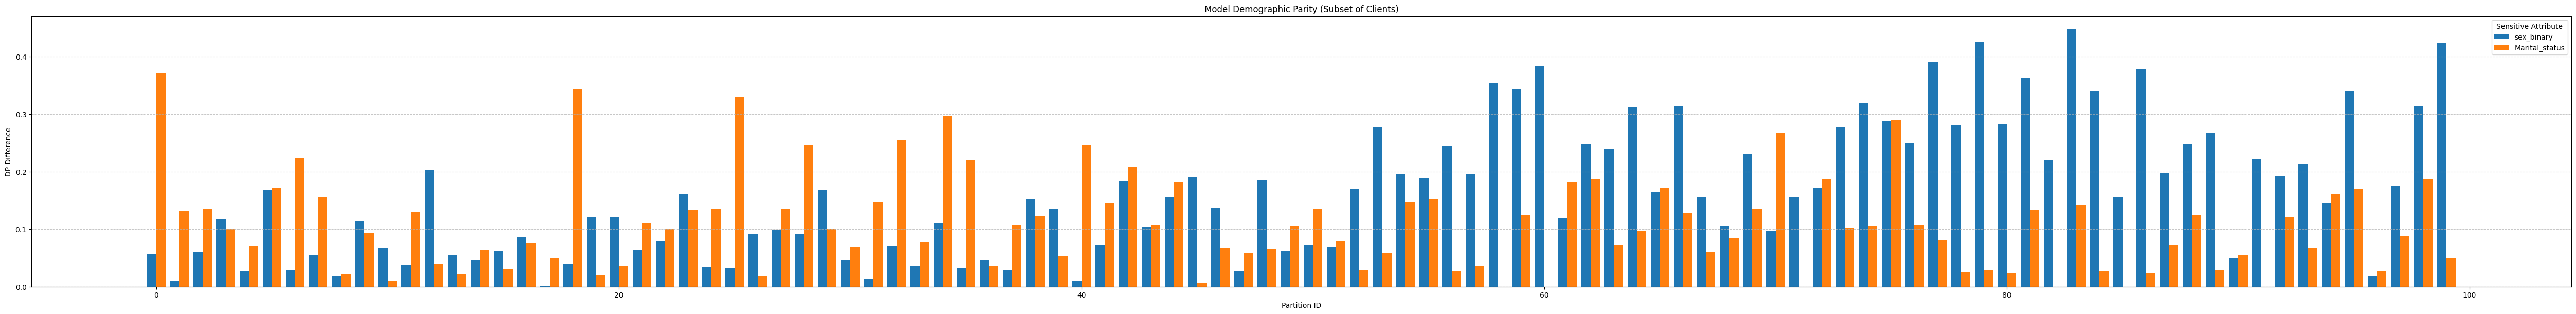

In [4]:
print("\nGenerating fairness plots (Model Fairness)...")

# Evaluate Model DP
fig_dp, _, df_results = plot_multi_attribute_fairness(
    partitioner=fds.partitioners["train_train"],
    partitioner_test=fds.partitioners["train_test"],
    label_name="occupation_binary",
    sens_atts=["sex_binary", "Marital_status"],
    fairness_metric="DP",
    model=LogisticRegression(max_iter=1000, solver="liblinear"),
    max_num_partitions=num_clients,  # Plot first 20 for readability
    title="Model Demographic Parity (Subset of Clients)",
    fds=fds,
    split="train_train",
    test_split="train_test",
)

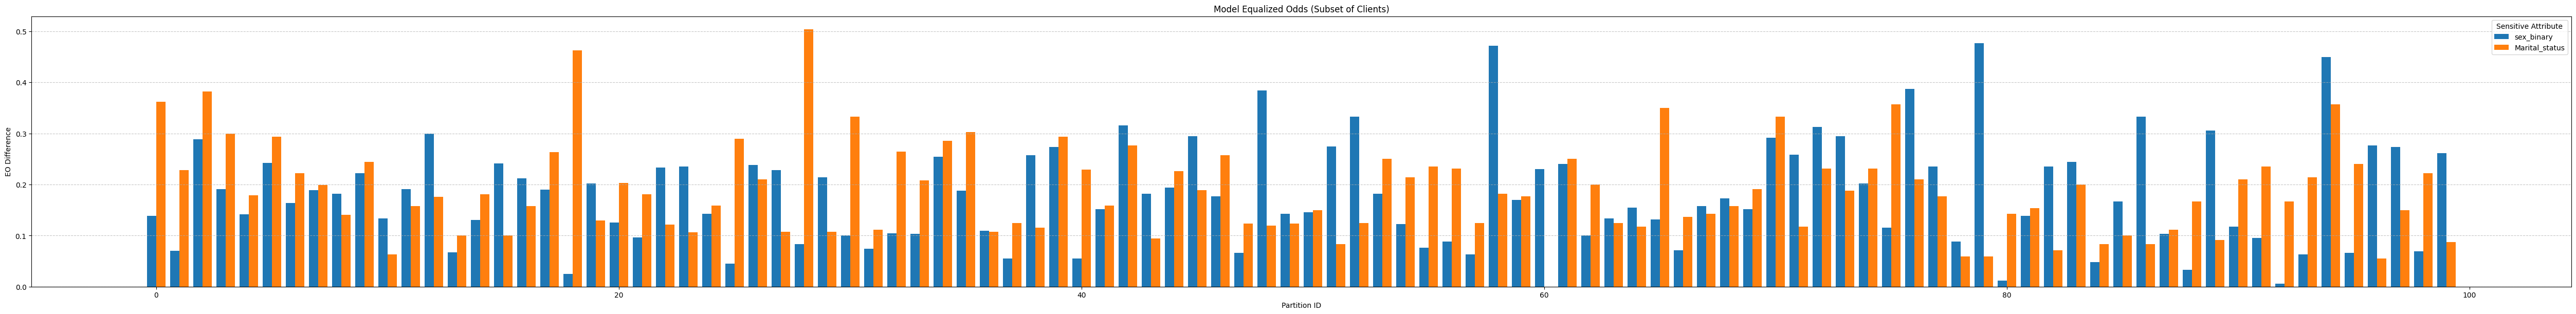

In [5]:
fig_eo, _, _ = plot_multi_attribute_fairness(
    partitioner=fds.partitioners["train_train"],
    partitioner_test=fds.partitioners["train_test"],
    label_name="occupation_binary",
    sens_atts=["sex_binary", "Marital_status"],
    fairness_metric="EO",
    model=LogisticRegression(max_iter=1000, solver="liblinear"),
    max_num_partitions=num_clients,
    title="Model Equalized Odds (Subset of Clients)",
    fds=fds,
    split="train_train",
    test_split="train_test",
)

In [6]:
THRESHOLD = 50
df_results["Group"] = ["Group A" if i < THRESHOLD else "Group B" for i in df_results.index]
print("\nSummary Statistics by Group:")
summary = df_results.groupby("Group")[["Accuracy", "sex_binary_DP", "Marital_status_DP"]].mean()
print(summary)


Summary Statistics by Group:
         Accuracy  sex_binary_DP  Marital_status_DP
Group                                              
Group A  0.772108       0.082356           0.123461
Group B  0.785299       0.240500           0.092067
